# ISIC 2024 - Stacking: the CNN score as a LightGBM feature

Blending averages the two models with one fixed weight for every lesion. With stacking, LightGBM gets the CNN's
out-of-fold score as an extra feature, so it can learn when to trust the image, for example more for lesions
where the metadata looks normal.

1. v3 features from `src/features.py` (same code as `03_lightgbm`)
2. CNN out-of-fold score as a feature
3. Stack v1: v3 features + CNN score
4. Stack v2: + the CNN score compared to the patient's other lesions
5. Comparison with LightGBM, the CNN and the blend
6. Feature importance and saving

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

sys.path.insert(0, '../src')
from isic_pauc import p_auc_tpr
from features import build_features

DATA_DIR = '../data'
SEED = 42
N_FOLDS = 5

## 1. v3 features
`build_features` does the same as `03_lightgbm`: drops the leaky columns, sets the categorical columns and adds
the engineered and patient-normalized features.

In [2]:
train = pd.read_csv(f'{DATA_DIR}/train-metadata.csv', low_memory=False)
test = pd.read_csv(f'{DATA_DIR}/test-metadata.csv')
folds = pd.read_csv(f'{DATA_DIR}/folds.csv')

train = train.merge(folds[['isic_id', 'fold']], on='isic_id', how='left')
df, features_v3 = build_features(train, test)

print(len(features_v3))   # should be 57 like in 03
df.shape

57


(401059, 65)

## 2. CNN score as a feature
The CNN score of every lesion comes from a CNN that didn't see that lesion during training.

There is still a small leak: when LightGBM trains on folds 1-4 and validates on fold 0, the CNN scores of the
training rows came from CNNs that did see fold 0 (for example, the CNN that scored fold 2 was trained on folds 0, 1,
3 and 4). Doing it fully correctly (nested cross-validation) would need 20 CNN trainings instead of 5. This is how
stacking with out-of-fold predictions is normally done and the effect should be small, but the stacking scores
can be a little optimistic.

In [20]:
oof_cnn = pd.read_csv(f'{DATA_DIR}/oof_cnn.csv')

df = df.merge(oof_cnn[['oof_cnn', 'isic_id']].rename(columns={'oof_cnn': 'cnn'}), on='isic_id', how='inner')

assert df['cnn'].notna().all() and len(df) == 401059

## 3. Cross-validation function
Same function as in `03_lightgbm` (downsampling to 1% of the benign lesions, same parameters).

In [5]:
BASE_PARAMS = {
    'objective': 'binary',
    'learning_rate': 0.05,
    'n_estimators': 300,
    'num_leaves': 31,
    'min_child_samples': 20,
    'subsample': 0.8,
    'subsample_freq': 1,
    'colsample_bytree': 0.8,
    'random_state': SEED,
    'verbose': -1,
}


def run_cv(df, features, params=BASE_PARAMS, name='model', neg_frac=0.01):
    oof = np.zeros(len(df))
    paucs, aucs = [], []
    models = []

    for fold in range(N_FOLDS):
        trn = df[df['fold'] != fold]
        val = df[df['fold'] == fold]

        if neg_frac is not None:
            trn = pd.concat([trn[trn['target'] == 1], trn[trn['target'] == 0].sample(frac=neg_frac, random_state=SEED)])

        model = lgb.LGBMClassifier(**params)
        model.fit(trn[features], trn['target'])

        pred = model.predict_proba(val[features])[:, 1]
        oof[(df['fold'] == fold).to_numpy()] = pred

        pauc = p_auc_tpr(val['target'], pred, 0.80)
        auc = roc_auc_score(val['target'], pred)

        paucs.append(pauc)
        aucs.append(auc)
        models.append(model)
        print(f'{name} fold {fold}: pAUC={pauc:.4f}  AUC={auc:.4f}')

    print(f'{name}  pAUC: {np.mean(paucs):.4f} +/- {np.std(paucs):.4f}   AUC: {np.mean(aucs):.4f} +/- {np.std(aucs):.4f}')
    return {'name': name, 'paucs': paucs, 'aucs': aucs, 'oof': oof, 'models': models}

In [6]:
# sanity check: should give the same 0.1644 as lgbm_v3 in 03
res_v3 = run_cv(df, features_v3, name='lgbm_v3')

lgbm_v3 fold 0: pAUC=0.1688  AUC=0.9596
lgbm_v3 fold 1: pAUC=0.1529  AUC=0.9401
lgbm_v3 fold 2: pAUC=0.1689  AUC=0.9610
lgbm_v3 fold 3: pAUC=0.1741  AUC=0.9664
lgbm_v3 fold 4: pAUC=0.1573  AUC=0.9452
lgbm_v3  pAUC: 0.1644 +/- 0.0079   AUC: 0.9545 +/- 0.0100


## 4. Stack v1: v3 features + CNN score

In [7]:
res_stack1 = run_cv(df, features_v3 + ['cnn'], name='stack_v1')

stack_v1 fold 0: pAUC=0.1791  AUC=0.9713
stack_v1 fold 1: pAUC=0.1632  AUC=0.9525
stack_v1 fold 2: pAUC=0.1777  AUC=0.9710
stack_v1 fold 3: pAUC=0.1773  AUC=0.9707
stack_v1 fold 4: pAUC=0.1544  AUC=0.9432
stack_v1  pAUC: 0.1703 +/- 0.0098   AUC: 0.9618 +/- 0.0117


## 5. Stack v2: "ugly duckling" on the CNN score
How suspicious does the CNN think this lesion is compared to the patient's other lesions?
`(cnn - patient mean) / (patient std + 1e-6)`. All lesions of a patient are in the same fold, so their CNN scores
come from the same CNN model.

In [15]:
df['cnn_pnorm'] = df.groupby('patient_id')['cnn'].transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))

res_stack2 = run_cv(df, features_v3 + ['cnn', 'cnn_pnorm'], name='stack_v2')

stack_v2 fold 0: pAUC=0.1772  AUC=0.9701
stack_v2 fold 1: pAUC=0.1622  AUC=0.9518
stack_v2 fold 2: pAUC=0.1768  AUC=0.9700
stack_v2 fold 3: pAUC=0.1764  AUC=0.9686
stack_v2 fold 4: pAUC=0.1545  AUC=0.9439
stack_v2  pAUC: 0.1694 +/- 0.0094   AUC: 0.9609 +/- 0.0110


## 6. Compare
Everything on the same folds. The blend numbers come from `oof_blend.csv` (`05_blend`).

In [21]:
oof_blend = pd.read_csv(f'{DATA_DIR}/oof_blend.csv')


def paucs_from_column(frame, col):
    return [p_auc_tpr(frame.loc[frame['fold'] == f, 'target'], frame.loc[frame['fold'] == f, col], 0.80)
            for f in range(N_FOLDS)]


compare = pd.DataFrame({
    'lgbm_v3': res_v3['paucs'],
    'cnn': paucs_from_column(oof_cnn, 'oof_cnn'),
    'blend': paucs_from_column(oof_blend, 'blend'),
    'stack_v1': res_stack1['paucs'],
    'stack_v2': res_stack2['paucs'],
}, index=[f'fold {i}' for i in range(N_FOLDS)])

compare.loc['mean'] = compare.iloc[:N_FOLDS].mean()
compare.loc['std'] = compare.iloc[:N_FOLDS].std(ddof=0)
compare.round(4)

,lgbm_v3,cnn,blend,stack_v1,stack_v2
fold 0,0.1688,0.1496,0.1744,0.1791,0.1772
fold 1,0.1529,0.1586,0.1633,0.1632,0.1622
fold 2,0.1689,0.1516,0.1752,0.1777,0.1768
fold 3,0.1741,0.1350,0.1738,0.1773,0.1764
fold 4,0.1573,0.1212,0.1588,0.1544,0.1545
mean,0.1644,0.1432,0.1691,0.1703,0.1694
std,0.0079,0.0134,0.0067,0.0098,0.0094


- Stack v1 (v3 features + CNN score) has the best mean pAUC so far, 0.1703 +/- 0.0098. That is +0.006 over
  LightGBM alone (better on 4 of 5 folds) but only +0.0012 over the blend, which is far below the fold-to-fold
  std. It is better than the blend on 3 folds, the same on fold 1 and worse on fold 4 (0.1544 vs 0.1588), and it
  has the small leak from above, so blending and stacking are basically a tie.
- Stack v2 didn't improve on stack v1 (0.1694), even though `cnn` and `cnn_pnorm` are the two most important
  features by far. Both columns carry mostly the same information, so LightGBM just splits its trust between them.
  A high importance doesn't mean a feature adds something new.
- Every combination beats LightGBM alone, so the images add information the scanner measurements don't have.

## 7. Feature importance of stack v2
Where do `cnn` and `cnn_pnorm` rank compared to the metadata features?

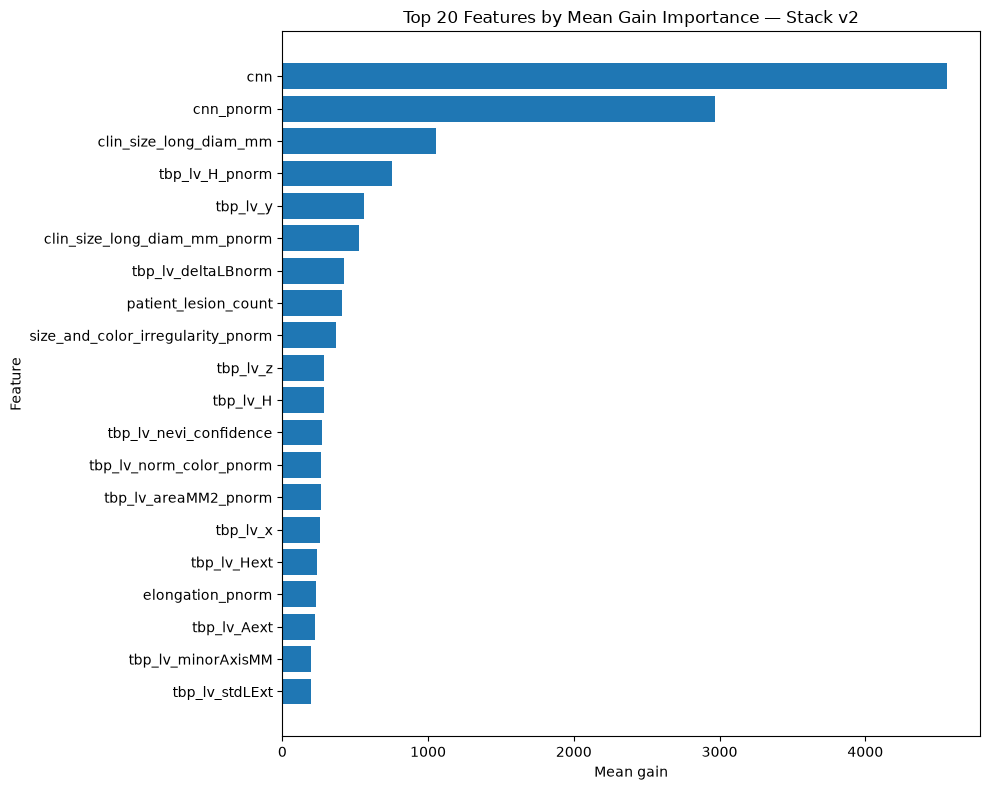

In [22]:
importance = (
    pd.DataFrame([
        model.booster_.feature_importance(importance_type='gain')
        for model in res_stack2['models']
    ], columns=res_stack2['models'][0].booster_.feature_name())
    .mean()
    .sort_values(ascending=False)
)

top20 = importance.head(20).sort_values()

plt.figure(figsize=(10, 8))
plt.barh(top20.index, top20.values)
plt.xlabel('Mean gain')
plt.ylabel('Feature')
plt.title('Top 20 features by mean gain importance - stack v2')
plt.tight_layout()
plt.show()

## 8. Save
Saving stack v1, the better of the two stacks.

In [26]:
oof_stack = df[['isic_id', 'patient_id', 'target', 'fold']].copy()
oof_stack['oof'] = res_stack1['oof']

oof_stack.to_csv('../data/oof_stack.csv', index=False)

pd.read_csv('../data/oof_stack.csv').head()

,isic_id,patient_id,target,fold,oof
0,ISIC_0015670,IP_1235828,0,1,0.000010
1,ISIC_0015845,IP_8170065,0,4,0.999099
2,ISIC_0015864,IP_6724798,0,4,0.000016
3,ISIC_0015902,IP_4111386,0,1,0.000030
4,ISIC_0024200,IP_8313778,0,1,0.000009
